# MT3510 Group Project Report


## **Introduction**
This report will explore **Deterministic Finite Automata (DFA)**, an important concept in theoretical computer science and mathematics. A DFA is a finite state machine that takes in string of symbols and accepts or rejects the string based on the sequence of states. DFAs have many practical applications, including recognising formal languages, malware detection, text processing, user interface and compilers. The theoretical foundations were laid by the work of Alan Turing in the 1930s, creating the Turing machine, which helped in the development of finite state machines that became essential for early computer engineers.

We will specifically explore how to identify a **synchronising DFA**, a special type of DFA that contains a reset word in its alphabet. The Cerny Conjecture states that $(n-1)^2$ is the largest length of a reset word for a DFA with n states. The conjecture made by Jan Cerny in 1969 still remains an unsolved problem in Computer science. We will discover that synchronizing DFAs correspond to a transformation semigroup, a set of functions that is closed under composition and contains a constant map (if synchronizing). One of the methods used involves creating a pair digraph for a DFA to identify if the given DFA is sychronizing. This involves finding a transformation that sends any pair of states to the same state.

We will also be exploring **isomorphisms** between two DFAs that have various levels of strictness, determining if synchronizing is an invariant property. Specifically, we will analyse strict, weak and semi isomorphisms, which allows us to compare DFAs and evaluate their properties.

## 2. Description of Implementation


### 2.1.1 Transition Monoid Implementation 
To test if a given DFA is synchronizing, we want to find a transformation $T$ in the transition monoid that is constant. Meaning $T(q) = x$ for any state $q \in Q$.
To test if such a transformation exists, we will use a BFS algorithm.

**The general idea is:**
- For each add $a \in\Sigma$ add $a$ to the queue.
  
- We want to check if the transformation associated with this word is constant:

  
   - Check this by looking at where each transformation maps each $q$
     
   - Then by taking the set of those images: $im(T) = \{T(q) : q \in Q\}$, if the size of this set is 1, we know it maps all $q \in Q$ to the same state
 
   - Therefore giving us a reset word corresponding to a constant transformation
 
- If this image isn't of size 1, then we don't have a constant transformation.

- We should compose the transformation we have just examined with every $a \in\Sigma$ and add these to the queue (giving us longer words)

- Repeating the above steps for every word in the queue will show us if the DFA is synchronizing.

- This algorithm will eventually terminate as even though we are adding longer words to the queue, we are actually adding the transformation associated with that word.

- This means if a longer word corresponds to a transformation already seen, its removed from the queue and not composed with any letters again.

### 2.1.2 Image of States Implementation ###

Another way of testing if a given DFA is synchronising is by using breadth-first search, BFS, over a subsets of states and applying each input letter $a$ in $\Sigma$ to all states simultaneously in a subset and seeing if it results in a subset of size 1.

**The general idea:**
- Start with a tuple of the states $Q$ in the queue

- Move through the subsets in the queue until you arrive at one that hasn't been checked yet

- When you find a subset that hasn't been checked, we add it to a list of checked subsets and see if it has length 1, if it does we stop as DFA is synchronising and so return True, otherwise we continue

- Compute the image of the subset under each letter $a$ in $\Sigma$ and if the image of the subset (another subset) hasn't been seen before, we add it to the end of the queue

- Repeat the process

- If the queue finishes without finding a subset of size 1, then the DFA isn't synchronising and so return False

### 2.1.3 Ancestor Method Implementation
This Ancestor Method Implementation is a modified 'Image of States Implementation' which checks if a DFA is synchronising as before but also returns the shortest-length synchronising word. 

**The general idea:**

- Everything is the same as the 'Image of States Implementation' except for the addition of the following:

   - Creation of a dictionary for recording each subset and the subset it immediately came from
 
   - Creation of an empty dictionary which will store each subset and the letter applied to reach it
 
   - Upon finding a subset of length 1, start creating the return word by working backwards from the current subset to the original subset, recording all of the letters and then reversing the list. Then create a string out of all the items in this list
 
   - After checking that the image we computed hasn't been seen before, add it's ancestor and letter applied to respective dictionaries
 
**Note:** The word that this function returns will always be a shortest-length synchronising word due to the very nature of BFS, this is not the case with depth-first search, DFS

### 2.1.4 Pair Graph Implementation

We aim to explore Deterministic Finite Automaton using the pair graph. The first of the functions we define will take care of determining whether or not a DFA is synchronizing, and the second will return a reset word if one exists.

This method is made possible by the following theorem.

Theorem: Suppose that for every pair of two distinct states $q_1, q_2 \in Q$ you can find a word $w_{q_1, q_2}$ over $\Sigma$ such that reading $w_{q_1, q_2}$ from either state leaves you in a common state $q_s$. Then $A$ is synchronizing. 

**The general idea:**

* Iterate through each unique pair $(q_1, q_2)$ for distinct states $q_1$, $q_2$ $\in S$.

* For each pair, perform a BFS using $\Sigma$.

* Find if there is a word $w$ such that $\tau(q_1, w) = \tau(q_2, w)$.

* If any unique pair does not satisfy $\tau(q_1, w) = \tau(q_2, w)$, for some $w$, in other words if there exits a pair that cannot be merged, then the DFA is not synchronizing. 

* Else each unique pair may be merged and the DFA is therefore synchronizing as per the above theorem.

To find a resest word, the procedure is very similar and most of the structure is the same. 

The function finds and returns a reset word for the given DFA by starting from the set of all states, $Q$, and applying words to merge pairs until the set collapses to one state $\{q_s\}$. The below implementation starts with the merging of arbitrary states, and does not optimise the order of pairs merged in any way to reduce the length of the reset word it finds. The greedy heuristics of this method do not guarantee that the reset word found will be the shortest however it will always find a valid reset word by working forward from an arbitrary pair of states.

This is in contrast to the ancestor method which uses a BFS on all possible singleton sets $\{q_i\}$ for $1 \leq i \leq |Q|$. This backward search will find the shortest reset word, as it checks paths in increasing length (Breadth-First). 

**The general idea:**

* Begin with the start state, $S = Q$.

* Choose two arbitrary distinct states $q_1$ and $q_2$ $\in S$.

* Implement a BFS to find the shortest word $w$ that merges $q_1$ and $q_2$.

* Apply the word $w$ to every state in the current set $S$ to obtain a new set.

    $S_{new} = \{\tau(q, w) : q \in S\}$.

* Repeat and continue until $|S| = 1$

**Note**: although the BFS finds the shortest word to merge two states in one step, the method will not merge all states to $\{q_s\}$ in the shortest possible number of uses of $\alpha \in \Sigma$.

### 2.2.1 Strict Isomorphism Implementation

We aim to find if two given DFAs are strictly isomorphic. To do this, we will test for if there exists an isomorphism between the DFAs.

**The general idea:**

- Define a function is_strict_isomorphism to test if two DFAs $A_1$ and $A_2$ are strictly isomorphic

- First verify the DFAs indeed have a common alphabet

*To be strictly isomorphic*

- Need a bijection from $Q_1$ to $Q_2$, so must have same cardinalities ($|Q_1|=|Q_2|$), return False if not

- Need $f(F_1)=F_2$, since $f$ is bijection, must have $|F_1|=|F_2|$, return False if not

Now we can construct the mapping $f$ using backtrack search

**Note:** that we assumed that $Q={0,1,...,n-1}$ for some natural number $n$, with $|Q_1|=|Q_2|$ if $f$ is an injection, it is a bijection

- Create a list to track the used Q2 states, this insures injectivity of $f$

- Want $f$ to map $(q_s)_1$ to $(q_s)_2$, set $f((q_s)_1)=(q_s)_2$, mark $(q_s)_2)$ as used

- Define the recursive backtracking function, $dive(v)$, on a vertex $v$

- $dive(v)$ does:
  - check if every state is mapped, if that happens, verify isomorphism conditions on $f$, returning True if passes all

  - if not, then if $v$ already mapped then move to next, until an unmapped vertex is found
 
  - using a loop, try every *unused* state $x$ of $Q_2$ as image of $v$ under $f$, verifing the isomorphism conditions hold, if violated, break out and try the next $x$
 
  - do these two lines: 1. 'if $dive(v+1)$: return True', and after that 2. revert the changes i.e. $f[v]$ to $-1$ and set "usedness" of $x$ back to unusued (this line will only be done if False is returned)

  - these two lines are crucial, since $dive(v+1)$ will eventually reach line 1, which procedes with $dive(v+2)$ and so on. Finally $dive(n)$ will be reached, this is the 'every(last) vertex is mapped' case, now dive verifies the isomorphism conditions and either return a True or a False
 
  - if True is returned we found a solution, so propagate the True upwards so that $dive(v)$ returns True
 
  - if False is returned, this is a dead end, all possible constructions from $f[v]=x$ has failed, hence does line 2 (which can be interpreted as going one step back), and explores other possiblities. This might succeed or have to go further back.
 
  - lastly $dive(v)$ returns False. This will only be triggered if all possible constructions from $v$ has failed, hence $v$ is a dead end, so need to move back, to $v-1$.

Now out of dive

- if $dive(0)$ is True, return True and f, else, return False

- this will either fully construct $f$ and return a True, or will exhaust all possible constuctions from $0$ and finally having $dive(0)$ returning a False, explaining the above line.

**Discussion about exsistance of a bijection**

Since being strictly isomorphic means 'there exists an isomorphism between the DFAs' and we constucted a specific one. If the $f$ constructed fails to be an isomorphism, could there still exist an isomorphism $g$, making the DFAs isomorphic? 

To explain this, note that backtracking search exhausts every possible bijection, so is_strict_isomorphism searches *every* bijection that maps $(q_s)_1$ to $(q_s)_2$. It tries every possible mapping to an unmapped state, with this, if an isomorphism existis, it *will* find one. So returning a False really means there does not exist such an isomorphism.


In [1]:
def is_strict_isomorphism(A1,A2):
    """
    Tests if two DFAs A1=(Q1,Σ,τ1,qs1,F1) and A2=(Q2,Σ,τ2,qs2,F2) are strictly isomorphic.
    Assumes they have the common alphabet Σ.
    Assumes every state in Q is reachable from qs.
    Uses backtrack search.

    Parameters:
    - A1, A2: Two DFAs
    Arguments of A1, A2:
    - Q1, Q2: some finite set of states
    - Σ: some finite alphabet (a set)
    - τ1, τ2: transition function τi:Qi×Σ→Qi for i=1,2 (a dict)
    - qs1,qs2: start state
    - F1, F2: set of accepting or final states

    Returns: 
    Boolean True or False. If True, also the isomorphism f
    """
    # Store the arguments of the DFAs in variables(if not already in this form)
    Q1,Σ1,τ1,qs1,F1 = A1
    Q2,Σ2,τ2,qs2,F2 = A2
    # Common alphabet
    if Σ1 != Σ2:
        return False, None
    Σ = Σ1
    # Test the cardinalities of the Qs and the Fs are equal
    if len(Q1)!=len(Q2):
        return False, None
    if len(F1) != len(F2):
        return False, None
    # Build the mapping, since Q1 = Q2 = {0,1,...,n-1}, injective implies bijective.
    n = len(Q1)
    f = [-1]*n   # for q in Q1, f[q]=f(q), the image of q in Q2, -1 means not mapped yet.
    used = [False] * n   # Track which states of Q2 are already used, ensures f injective, hence bijective
    # Map qs1 to qs2 i.e. f(qs1)=qs2
    f[qs1] = qs2
    used[qs2] = True
    # Define the recursive backtracking function
    def dive(v):   # v is a vertex/state, will run dive from v=0
        if v == n:   # If we have mapped all vertices, verify the conditions are satisfied
            for q in Q1:
                if (q in F1)!=(f[q] in F2):
                    return False
                for a in Σ:
                    if τ2[(f[q], a)] != f[τ1[(q, a)]]:
                        return False
            return True   # f satisfies the conditions and is a bijection, i.e. isomorphism, so A1 A2 stricly isomorphic.
        if f[v] != -1:
            return dive(v+1)     # If the current vertex is already mapped, skip to the next
        # Try every unused state in Q2, x, as a image for v (i.e. to see if we can set f(v)=x)
        for x in Q2:
            if used[x]:   
                continue   # x has been used, get a new x
            # Check f(F1)=F2, if false can jump right into next loop, saving time 
            if (v in F1) != (x in F2):
                continue
            # Check consistency with already mapped vertices u in Q1
            consistent = True
            for u in Q1:
                if f[u] == -1:
                    continue   # Find those mapped vertices, skipping the unmapped
                for a in Σ:
                    if τ1[(u,a)] == v:   # If from u we go to v on some symbol,
                        if τ2[(f[u],a)] != x:
                            consistent = False   # x is not f(v), since f(v)=f(τ1(u,a))=τ2(f(u),a)
                            break
                    if τ1[(v,a)] == u:   # If from v we go to u on some symbol,
                        if τ2[(x,a)] != f[u]:   
                            consistent = False   # if x=f(v), then f(u)=f(τ1(v,a))=τ2(f(v),a)=τ2(x,a)
                            break
                if not consistent:   # If consistent is False, break out immediately, if True, loop on with next u.
                    break
            if not consistent:   # If consistent is False, this x is inconsistent, go to next x
                continue
            # If reaches here, consistent is True throughout, so try to map v to x, then run dive reapeatedly.
            f[v] = x
            used[x] = True
            if dive(v+1):
                return True   # To reach here, must reached v=n and f[v:n] satisfies the isomorphism conditions.
            f[v]=-1   # Reaching here implies that something went wrong in the if dive(v+1), dive(v+2),...loops
            used[x] = False    # so this x does not work try with another x and all the succeeding vs and xs are reverted
        # Reaching here means that no x worked, so v cant have a image satisfying the isomorphism conditions.
        return False   # This will show that v is a 'dead end' after every possible extenstion, so having to go to higher up (v-1)
    if dive(0): 
        return True, f   # f is fully constructed and is an isomorphism, strictly isomorphic
    else:
        return False, None   # Exhausted every path from 0 and no isomorphism found, so not isomorphic

### 2.2.2 Weak Isomorphism Implementation
Aim: Given two DFAs $A_1, A_2$, determine whether they are weakly isomorphic and, if so, return the bijections $f: Q_1 → Q_2$ and $g: Σ_1 → Σ_2$ such that: 
- $τ_2(f(q), g(a)) = τ_1(q,a)$ for all $q ∈ Q_1$ and all $a ∈ Σ_1$
- $f(q_s)_1 = (q_s)_2$
- $f(F_1) = F_2$

**Note:** To be weakly isomorphic, the bijections need a one-to-one correspondence, meaning $|Q_1| = |Q_2|, |Σ_1| = |Σ_2|$ and $|F_1| = |F_2|$, so the first stage of the function is checking these. The function will just return False is any of these cardinality tests fail.

This is done using a few main components:
1. A backtracking function - initally assume a solution for $f$ and $g$ works and check it works for each state. If a conflict occurs, the function will 'backtrack' (return False) and try the next possible solution until the function returns True or has exhausted all possible solutions.

2. Permutation method - permutate through each possible variations of $g$ until we have a solution that works. Since we are told to assume the length of $Σ$ will be much smaller than $Q$, cycling through all permutations of $Σ$ should not increase the time complexity too much.

3. Initially assuming $f(q_s)_1 = (q_s)_2$ for the potential solution, then checking this solution works for the backtrack search using this assumption. 

In [2]:
from itertools import permutations

def backtrack(Q1, Q2, f, seen, check):
    if len(f) == len(Q1): # solution works
        leftover1 = [q for q in Q1 if q not in f]
        leftover2 = [q for q in Q2 if q not in f.values()]
        f[leftover1[0]] = leftover2[0]
        return True

    q1 = Q1[len(f)] # get next value in Q1
    for q2 in Q2:
        f[q1] = q2 # get mapping of Q2 from Q1
        
        if check(f): # check the extention to the next state
            seen.add(q2)

            if backtrack(Q1, Q2, f, seen, check): # move to next state
                return True
                
            seen.remove(q2) # potential solution failed! retreat
        f.pop(q1)
    return False

def is_weak_isomorphic(A1, A2):
    """
    Tests if two DFAs A1 = (Q1, Σ1, τ1, qs1, F1) and A2 = (Q2, Σ2, τ2, qs2, F2) are weakly isomorphic.

    Weak isomorphism requires bijections f: Q1 → Q2 and g: Σ1 → Σ2 such that:
        -  τ2(f(q), g(a)) = f(τ1(q, a))  for all q ∈ Q1, a ∈ Σ1
        - f(qs1) = qs2
        - f(F1) = F2

    Returns: (True, f, g)  or  (False, None, None)
    """
    
    def weak_check(f): # check if τ2(f(q),g(a)) == f(τ1(q,a)) 
        for q1, q2 in f.items():
            for a1 in Σ1:
                a2 = g[a1]
                q1_next = τ1[(q1,a1)]
                if q1_next in f:
                    q2_next = τ2[(q2,a2)]
                    if f[q1_next] != q2_next:
                        return False
        return True

    Q1, Σ1, τ1, qs1, F1 = A1
    Q2, Σ2, τ2, qs2, F2 = A2
    Σ1 = list(Σ1)
    Σ2 = list(Σ2)
    F1 = list(F1)
    F2 = list(F2)

    if len(Q1) != len(Q2) or len(Σ1) != len(Σ2) or len(F1) != len(F2):
        return False, None, None

    for trial in permutations(Σ2): # trying different orders of Σ2 until one permutation matches
        g = dict(zip(Σ1, trial)) # set g = {Σ1 : trial}
        f = {qs1: qs2} # assuming f(qs1) == qs2 !!
        seen = {qs2}

        # since we have already used qs1 and qs2, we can remove them from Q1 and Q2
        Q1n = [q for q in Q1 if q != qs1]
        Q2n = [q for q in Q2 if q != qs2]
        
        # backtrack search to see if f and g are solutions
        if backtrack(Q1n, Q2n, f, seen, weak_check):
            for end1 in F1: # checking f(F1) == F2
                if f[end1] not in F2:
                    return False, None, None
            return True, f, g

    return False, None, None

### 2.2.3 Semi-Isomorphism Implementation
Aim: Given two DFAs $A_1$, $A_2$, determine whether they are semi-isomorphic and, if so, return the bijections $f: Q_1 → Q_2$ and $g: Σ_1 → Σ_2$.

Method: The algorithm works in the following manner:

### 1. Root Identification: 

We are given that there is a 'root' state from which all other states are reachable. 

 - Convert the two DFAs into directed graphs using the 'networkx' package.
 - Compute the Strongly Connected Components (SCCs) of each graph, strongly connected components are components from which all other states within the component are reachable from each other.
 - Construct the condensation graph, where each SCC is collapsed into a single node, $C$ is the set of SCCs.
 - Identify the SCC with out-degree of value $|C| - 1$, meaning it can reach all other SCCs. All states in this SCC are root candidates.

### 2. Backtrack Algorithm:

Choose a candidate pair of roots from the chosen SCC:
- $\text{root}_1 \in Q_1$ (from $A_1$)
- $\text{root}_2 \in Q_2$ (from $A_2$)
  
We set the mapping $f($root1$) = $ root2 for the candidate pair of roots. The algorithm then attempts to extend this into full bijections $f$ and $g$ using a backtracking search.


### 3. Backtracking Algorithm

The backtracking algorithm incrementally constructs the bijections $f$ and $g$ while ensuring consistency with the transition functions.

- For each mapped pair of states $(q_1, q_2)$:
  - For each symbol $a \in \Sigma_1$:
    - Try to assign a symbol $b \in \Sigma_2$ such that:
      $$
      f(\delta_1(q_1, a)) = \delta_2(q_2, b)
      $$

- During this process, if $a$ is already mapped by $g$, reuse the mapping, otherwise, try all unused symbols in $\Sigma_2$.

- If a conflict occurs, the algorithm 'backtracks' (returns) to the previous step and tries to a different mapping,

- The algorithm continues until complete bijections for both $f$ and $g$ are found, or all possible root pairings and mappings have been exhausted and the no semi-ismorphisms exist.


In [20]:
import networkx as nx

def is_semi_isomorphism(A1, A2):
    """
    Tests if two DFAs A1=(Q1,Σ1,τ1,qs1,F1) and A2=(Q2,Σ2,τ2,qs2,F2) are semi-isomorphic.

    Semi-isomorphism requires bijections f: Q1 → Q2 and g: Σ1 → Σ2 such that:
        τ2(f(q), g(a)) = f(τ1(q, a))  for all q ∈ Q1, a ∈ Σ1

    Start states and final states are ignored.
    Assumes that in each DFA there is at least one state that can reach all other states.

    Returns: (True, f, g)  or  (False, None, None)
    """
    Q1, sigma1, tau1, qs1, F1 = A1
    Q2, sigma2, tau2, qs2, F2 = A2

    if len(Q1) != len(Q2) or len(sigma1) != len(sigma2):
        return False, None, None

    # Build directed multigraphs for SCC analysis
    G1 = nx.MultiDiGraph()
    for q in Q1:
        for a in sigma1:
            G1.add_edge(q, tau1[(q, a)], label=a)

    G2 = nx.MultiDiGraph()
    for q in Q2:
        for a in sigma2:
            G2.add_edge(q, tau2[(q, a)], label=a)

    sccs1 = list(nx.strongly_connected_components(G1))
    sccs2 = list(nx.strongly_connected_components(G2))
    C1 = nx.condensation(G1, scc=sccs1)
    C2 = nx.condensation(G2, scc=sccs2)

    # Find states that can reach all others (root candidates)
    reaching_states1 = []
    reaching_states2 = []

    for node in C1.nodes():
        if len(nx.descendants(C1, node)) == len(C1.nodes()) - 1:
            reaching_states1.extend(sccs1[node])

    for node in C2.nodes():
        if len(nx.descendants(C2, node)) == len(C2.nodes()) - 1:
            reaching_states2.extend(sccs2[node])

    for root1 in reaching_states1:
        for root2 in reaching_states2:
            f = {root1: root2}
            queue = [(root1, a) for a in sigma1]
            result = _backtrack_semi(f, {}, queue, tau1, tau2, sigma1, sigma2, Q1)
            if result is not None:
                return True, result[0], result[1]

    return False, None, None


def _backtrack_semi(f, g, queue, tau1, tau2, sigma1, sigma2, Q1):
    """Recursive backtracking helper for is_semi_isomorphism."""
    if not queue:
        if (len(f) == len(Q1) and len(g) == len(sigma1)
                and len(set(f.values())) == len(Q1)
                and len(set(g.values())) == len(sigma1)):
            return f, g
        return None

    q, a = queue[0]
    rest = queue[1:]
    fq = f[q]
    q_next = tau1[(q, a)]

    if a in g and q_next in f:
        # Case 1: both g(a) and f(q_next) already known — just verify
        if tau2[(fq, g[a])] != f[q_next]:
            return None
        return _backtrack_semi(f, g, rest, tau1, tau2, sigma1, sigma2, Q1)

    elif a in g and q_next not in f:
        # Case 2: g(a) known, f(q_next) unknown — determine f(q_next) from τ2
        target = tau2[(fq, g[a])]
        if target in f.values():
            return None
        new_f = {**f, q_next: target}
        return _backtrack_semi(new_f, g, rest + [(q_next, b) for b in sigma1],
                               tau1, tau2, sigma1, sigma2, Q1)

    elif a not in g and q_next in f:
        # Case 3: f(q_next) known, g(a) unknown — try all unused symbols
        target = f[q_next]
        for b in sigma2:
            if b not in g.values() and tau2[(fq, b)] == target:
                result = _backtrack_semi(f, {**g, a: b}, rest,
                                         tau1, tau2, sigma1, sigma2, Q1)
                if result is not None:
                    return result
        return None

    else:
        # Case 4: neither known — try all unused (b, target) pairs
        for b in sigma2:
            target = tau2[(fq, b)]
            if b not in g.values() and target not in f.values():
                new_f = {**f, q_next: target}
                new_g = {**g, a: b}
                new_queue = rest + [(q_next, b2) for b2 in sigma1]
                result = _backtrack_semi(new_f, new_g, new_queue,
                                         tau1, tau2, sigma1, sigma2, Q1)
                if result is not None:
                    return result
        return None


## 3. Code


### 3.1.1 Transition Monoid (a)

In [21]:
def breadth_first_synch_test(A):
    #Start by converting the 5-tuple into each of its elements
    Q, sigma, tau, qs, F = A
 
    #defining the corresponding transformation ta to the letter a
    def transformation_of_letter(a):
        return{q: tau[(q,a)] for q in Q}

    #defining composition of transformations
    def composition_f_o_g(f,g):
        return {q: f[g[q]] for q in Q}
    
    transformations_checked = set()
    queue = [transformation_of_letter(a) for a in sigma]
    
    while queue:
        #remove first transformation from queue
        f = queue.pop(0)
        #convert that transformation to a tuple of the form
        #((q0,f(q0)),(q1,f(q1)),...,(qn,f(qn)))
       
        ftup = tuple(f.items())

        #if the transformation has been checked, go back to start of while loop
        if ftup in transformations_checked:
            continue

        #add transformation to the checked set
        transformations_checked.add(ftup)
        
        #look at the set of image values for the transformation, if |im(f)| = 1, then its constant
        if len(set(image for state,image in ftup)) == 1:
            return True
        #composing the transformations for each letter a with the f being currently examined: ta(f(q))
        for a in sigma:
            ta = transformation_of_letter(a)
            composedtransformation = composition_f_o_g(ta, f)
            queue.append(composedtransformation)
            
    return False

### 3.1.2 Image of States (b)

In [22]:
def breadth_first_synch_test_method2(A):
    #Start by converting the 5-tuple into each of its elements
    Q, sigma, tau, qs, F = A
    '''
    Using lots of code from breadth_first_synch_test
    Not including any of the local functions as will not be used
    '''

    #function to find image of subset under specified letter
    def image(f, a):
        return{tau[(q,a)] for q in f}

    #this time we will store subsets of states instead of transformations
    subsets_of_states_checked = set()

    
    list_queue = list(Q)
    list_queue.sort()
    queue = [tuple(list_queue)]


    while queue:
        #remove first subset from queue
        f = queue.pop(0)

        #if the current subset has been checked, go back to start of while loop
        if f in subsets_of_states_checked:
            continue

        subsets_of_states_checked.add(f)

        #if we find subset with only one state, DFA is synchronising 
        if len(f) == 1:
            return True

        #compute image of subset under each letter, sort it and convert to tuple
        for a in sigma:
            im = image(f, a)
            im = list(im)
            im.sort()
            im = tuple(im)

            #if a new subset, add to the queue
            if im not in subsets_of_states_checked:
                queue.append(im)
    #if no subset with 1 element found, DFA not synchronising
    return False

### 3.1.3 Ancestor Method (d)

In [23]:
def ancestor_method_with_rw(A):
    Q, sigma, tau, qs, F = A

    def image(f, a):
        return{tau[(q,a)] for q in f}

    subsets_of_states_checked = set()
   
    list_queue = list(Q)
    list_queue.sort()
    queue = [tuple(list_queue)]


    # implement ancestor method as 2 dictionaries; ancestor logs the subset and subset that it reached it from, and letter_taken_from_ancestor logs the subset and letter that was applied to reach it 
    ancestor = {queue[0]: False}
    letter_taken_from_ancestor = {}

    while queue:        
        f = queue.pop(0)
        
        if f in subsets_of_states_checked:
            continue

        subsets_of_states_checked.add(f)

        if len(f) == 1:
            # DFA synchronising, now we find return word that got us here
            
            return_word = []
            new_return_word = ""

            # for each subset, in order of most recent to first, creates list of letters taken from the previous subset one at a time until it backtracks to the first subset and reverse at the end since we read letters from end to start
            while ancestor[f] is not False:
                return_word.append(letter_taken_from_ancestor[f])
                f = ancestor[f]
            return_word.reverse()

            # convert letters in list to a string of them all joined together to create the return word
            for letter in return_word:
                new_return_word = new_return_word + letter
                
            return new_return_word

            
        for a in sigma:
            im = image(f, a)
            im = list(im)
            im.sort()
            im = tuple(im)
            
            # log ancestor of subset and letter applied to reach it in respective dictionaries before adding the subset to the queue
            if im not in subsets_of_states_checked:
                if im not in ancestor:
                    ancestor[im] = f
                    letter_taken_from_ancestor[im] = a
                queue.append(im)
                
    return False

### 3.1.4 Pair graph Method (c, e)

In [24]:
from collections import deque

def is_synchronising_by_pair_graph(A):
    
    # Unpack 5-tuple.
    Q, sigma, tau, qs, F = A
    Q = sorted(list(Q))
    n = len(Q)

    # Loop through every unique pair (q1, q2).
    for i in range(n):
        for j in range(i + 1, n):
            q1, q2 = Q[i], Q[j]

            # Check if pair is mergeable using BFS.
            queue = deque([(q1, q2)])
            visited = {tuple(sorted((q1, q2)))}
            found_merge = False

            while queue:
                current_q1, current_q2 = queue.popleft()

                # First check if the pair is merged.
                if current_q1 == current_q2:
                    found_merge = True
                    break

                # Apply letters in turn.
                for alpha in sigma:
                    next_q1 = tau[(current_q1, alpha)]
                    next_q2 = tau[(current_q2, alpha)]

                    # Check for a merge.
                    if next_q1 == next_q2:
                        found_merge = True
                        break

                    # Append new pair to the queue.
                    next_pair = tuple(sorted((next_q1, next_q2)))
                    if next_pair not in visited:
                        visited.add(next_pair)
                        queue.append(next_pair)
                        
                if found_merge:
                    break

            if not found_merge:
                # DFA is certainly not synchronizing.
                return False
                
    # All pairs can be merged.
    return True

In [25]:

def find_reset_word_by_pair_graph(A):
    
    # Unpack 5-tuple
    Q, sigma, tau, qs, F = A
    current_set = set(Q)
    reset_word = []

    while len(current_set) > 1:
        # Choose two arbitrary states.
        states_list = sorted(list(current_set))
        q1, q2 = states_list[0], states_list[1]
        
        # Find the shortest word to merge these two states using BFS.
        queue = deque([((q1, q2), [])])
        visited = {tuple(sorted((q1, q2)))}
        found_merge = False

        while queue:
            (current_q1, current_q2), path = queue.popleft()

            # Try every symbol in the alphabet.
            for alpha in sigma:
                next_q1 = tau[(current_q1, alpha)]
                next_q2 = tau[(current_q2, alpha)]

                if next_q1 == next_q2:
                    # Then q1 and q2 are merged, add letter to word.
                    merge_path = path + [alpha]
                    reset_word.extend(merge_path)

                    # Now apply the word to the whole set.
                    for step_alpha in merge_path:
                        current_set = {tau[(s, step_alpha)] for s in current_set}

                    found_merge = True
                    break

                next_pair = tuple(sorted((next_q1, next_q2)))
                if next_pair not in visited:
                    visited.add(next_pair)
                    queue.append((next_pair, path + [alpha]))

            if found_merge:
                break
        else: 
        # No reset word exists.
            return None
    return reset_word

## Effect of Isomorphism Type on Synchronisation

### Strict isomorphism
Strict isomorphism will **fully preserve** synchronization properties of DFAs (if at all). This is since two strictly isomorphic DFAs can be thought as renaming the states, with structures identical, so if a reset word exists in one, it also exists in the other, but probably  resets to a different state.

To explicitly show this,

- let $A_1=(Q_1,Σ,τ_1,(q_s)_1,F_1)$ and $A_2=(Q_2,Σ,τ_2,(q_s)_2,F_2)$ be strictly isomorphic, $f$ be an isomorphism between them.
- for $x∈Q_1$ define $t_1(x,w)=y$ to be "transition function of words", i.e using a word $w$ on a state $x$ gives state $y$. With $w=w_1w_2...w_n$ where each $w_i∈Σ$ for finite natural $i$, $t_1(x,w)$ is basically $τ_1(...(τ_1(τ_1(x,w_1),w_2),...,),w_n)$.
- Using induction on length of $w$, $t_2(f(q),w)=f(t_1(q,w))$ for all $q∈Q_1$ and all word $w$ over $Σ$ can be proven to hold, but too lengthy to write here.

If $A_1$ is synchronizing, there exists a reset word $w$ over $Σ$, and resets to a state $z∈Q_1$, i.e. $t_1(q,w)=z$ for all $q∈Q_1$. Then: $$f(z)=f(t_1(q,w))=t_2(f(q),w)$$ for all $f(q)=q_2∈Q_2$ (by surjectivity of $f$), so $w$ is a reset word and $f(z)∈Q_2$ is the state that is resetted to, hence $A_2$ is synchronizing.

### Weak isomorphism
Weak isomorphism will **fully preserve** synchronization properties of DFAs as well. This is due to two weakly isomorphic DFAs having the same structure, even if the two DFAs have different names for states and transition letters. Since they have the same starting and accepting states (when relabelled), if a synchronising word exists in one DFA, there will be a synchronising word that uses the bijections $f$ and $g$ to map the syncronising word into a relabelled version that is acceptable for the second DFA.

### Semi-isomorphism 
Since a semi-isomoprhism is defined by the two bijections $f: Q_1 → Q_2$ and $g: Σ_1 → Σ_2$, the defined mapping between the two DFAs conserves a synchronising word, for example, if a synchronising word $w'$ exists for $A_2$, the inverse mapping of $g^-1$ identifies the corresponding word $w$ in $A_1$.

This follows from:

* Structural Symmetry:
Since $f$ and $g$ are bijections, the two DFAs have identical structure. Therefore, if a sequence of transitions in $A_1$ leads all states to a single state, the corresponding sequence in $A_2$ must do the same.

* Edge Preservation:
Because transitions, edges and their labels are preserved under the bijections, the reset behaviour of the word is maintained. This guarantees that synchronising words are preserved.

* Bijective Property:
The converse also holds; if $A_1$ has a synchronising word, then $A_2$ has one and vice-versa, if $A_1$ does not have a synchronising word, then neither does $A_2$.

In conclusion, since semi-isomorphism preserves transitions, their origins, and destinations, the synchronisation behavior of the DFA is fully preserved.



## 4. Demonstration


### 4.1 Pair Graph - Examples 

The below example DFA will be used to demonstrate the functions 'is_synchronising_by_pair_graph' and 'find_reset_word_by_pair_graph'. This DFA was created at random however will return different reset words depending on the method used so is a good example of the efficiency of the pair graph method of finding a reset word. As discussed prior, the implementation of the 'find_reset_word_by_pair_graph' function does not perform a BFS to find the shortest possible reset word, as opposed to other methods, ie ancestry. For visualisation, the functions are modified to include prints at each iteration. This shows the reduction of $|Q|$ at each step.

In [26]:
Q = {0, 1, 2, 3, 4, 5}
sigma = {'a', 'b', 'c'}
tau = {(0, 'a'): 1, (0, 'b'): 0, (0, 'c'): 5,
       (1, 'a'): 2, (1, 'b'): 1, (1, 'c'): 3,
       (2, 'a'): 3, (2, 'b'): 1, (2, 'c'): 0,
       (3, 'a'): 4, (3, 'b'): 0, (3, 'c'): 2, 
       (4, 'a'): 5, (4, 'b'): 3, (4, 'c'): 4, 
       (5, 'a'): 0, (5, 'b'): 3, (5, 'c'): 5}
qs = {}
F = {}
A = (Q, sigma, tau, qs, F)

from collections import deque
def find_reset_word_by_pair_graph_print(A):
    
    # Unpack 5-tuple
    Q, sigma, tau, qs, F = A
    current_set = set(Q)
    reset_word = []

    print(f"{'Starting Set':<30} {'Pair to Merge':<20} {'Merge Word':<15} {'Resulting Set'}")
    while len(current_set) > 1:

        # Choose two arbitrary states.
        states_list = sorted(list(current_set))
        q1, q2 = states_list[0], states_list[1]
        
        # Find the shortest word to merge these two states using BFS.
        queue = deque([((q1, q2), [])])
        visited = {tuple(sorted((q1, q2)))}
        found_merge = False

        while queue:
            (current_q1, current_q2), path = queue.popleft()

            # Try every symbol in the alphabet.
            for alpha in sigma:
                next_q1 = tau[(current_q1, alpha)]
                next_q2 = tau[(current_q2, alpha)]

                if next_q1 == next_q2:
                    
                    # Then q1 and q2 are merged, add letter to word.
                    merge_path = path + [alpha]
            
                    reset_word.extend(merge_path)

                    set_before_merge = str(current_set)

                    # Now apply the word to the whole set.
                    for step_alpha in merge_path:
                        current_set = {tau[(s, step_alpha)] for s in current_set}

                    set_after_merge = str(current_set)
                    
                    print(f"{set_before_merge:<30} {str([q1, q2]):<20} {str(merge_path):<15} {set_after_merge}")
                
                    found_merge = True
                    break

                next_pair = tuple(sorted((next_q1, next_q2)))
                if next_pair not in visited:
                    visited.add(next_pair)
                    queue.append((next_pair, path + [alpha]))

            if found_merge:
                break
        else: 
        # No reset word exists.
            return None
            
    return reset_word

find_reset_word_by_pair_graph_print(A)

Starting Set                   Pair to Merge        Merge Word      Resulting Set
{0, 1, 2, 3, 4, 5}             [0, 1]               ['a', 'b']      {0, 1, 3}
{0, 1, 3}                      [0, 1]               ['a', 'b']      {1, 3}
{1, 3}                         [1, 3]               ['b', 'a', 'b'] {1}


['a', 'b', 'a', 'b', 'b', 'a', 'b']

Here is another example DFA, using the same modified `find_reset_word_by_pair_graph_print` function to determine a reset word. This example makes use of a Cerny Automaton, which is famously difficult to synchronise. Note that $|w|$ >> $|Q|$.

In [27]:
Q_cerny = {0, 1, 2, 3}
sigma_cerny = {'a', 'b'}
tau_cerny = {(0, 'a'): 1, (0, 'b'): 0,
       (1, 'a'): 2, (1, 'b'): 1,
       (2, 'a'): 3, (2, 'b'): 2,
       (3, 'a'): 0, (3, 'b'): 0}
qs = {}
F = {}
A_cerny = (Q_cerny, sigma_cerny, tau_cerny, qs, F)

find_reset_word_by_pair_graph_print(A_cerny)

Starting Set                   Pair to Merge        Merge Word      Resulting Set
{0, 1, 2, 3}                   [0, 1]               ['a', 'a', 'a', 'b'] {0, 1, 2}
{0, 1, 2}                      [0, 1]               ['a', 'a', 'a', 'b'] {0, 1}
{0, 1}                         [0, 1]               ['a', 'a', 'a', 'b'] {0}


['a', 'a', 'a', 'b', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'b']

### 4.1 Strict Isomorphism — Examples


In [28]:
# Function to report the output
def report_strict(A1, A2, label=""):
    ok, f = is_strict_isomorphism(A1, A2)
    result = "strictly isomorphic" if ok else "not strictly isomorphic"
    print(f"{label}  is  {result}")
    if ok:
        print(f"   f = {f}")
    print()

# Example 1: Different number of states. Expect: not strictly isomorphic.
# A1 has states {0,1,2}, A2 has states {0,1}
A1_ex1 = ({0,1,2}, {0,1}, {(0,0):1,(0,1):0,(1,0):0,(1,1):1,(2,0):1,(2,1):2}, 0, {0})
A2_ex1 = ({0,1}, {0,1}, {(0,0):1,(0,1):0,(1,0):0,(1,1):1}, 0, {0})
report_strict(A1_ex1, A2_ex1, "Example 1 (different number of states)")

# Example 2: Different start state. Expect: not strictly isomorphic.
# A1 starts at 0, A2 starts at 1.
A1_ex2 = ({0,1}, {0,1}, {(0,0):1,(0,1):0,(1,0):1,(1,1):0}, 0, {0})
A2_ex2 = ({0,1}, {0,1}, {(0,0):1,(0,1):0,(1,0):1,(1,1):0}, 1, {0})
report_strict(A1_ex2, A2_ex2, "Example 2 (different start state)")

# Example 3: Different accepting states. Expect: not strictly isomorphic.
# A1 accepts 0, A2 accepts 1.
A1_ex3 = ({0,1}, {0,1}, {(0,0):1,(0,1):0,(1,0):1,(1,1):0}, 0, {0})
A2_ex3 = ({0,1}, {0,1}, {(0,0):1,(0,1):0,(1,0):1,(1,1):0}, 0, {1})
report_strict(A1_ex2, A2_ex2, "Example 3 (different accepting states)")

# Example 4: Different transition function. Expect: not strictly isomorphic.
# States same but τ1(0,0)=1 and τ1(0,1)=0 but τ2(0,0)=0 and τ2(0,1)=1.
A1_ex4 = ({0,1}, {0,1}, {(0,0):1,(0,1):0,(1,0):1,(1,1):0}, 0, {0})
A2_ex4 = ({0,1}, {0,1}, {(0,0):0,(0,1):1,(1,0):1,(1,1):0}, 0, {0})
report_strict(A1_ex4, A2_ex4, "Example 4 (different transitions)")

# Examples 5: Renaming states. Expect: strictly isomorphic
A1_ex5 = ({0,1,2,3,4,5}, {0,1}, {(0,0):1,(0,1):0,(1,0):2,(1,1):4,(2,0):3,(2,1):4,(3,0):1,(3,1):4,(4,0):0,(4,1):5,(5,0):2,(5,1):0}, 0, {0,2,4})
A2_ex5 = ({0,1,2,3,4,5}, {0,1}, {(0,0):5,(0,1):1,(1,0):4,(1,1):3,(2,0):0,(2,1):1,(3,0):0,(3,1):4,(4,0):2,(4,1):4,(5,0):2,(5,1):1}, 4, {0,1,4})
report_strict(A1_ex5, A2_ex5, "Example 5 (renaming)")

Example 1 (different number of states)  is  not strictly isomorphic

Example 2 (different start state)  is  not strictly isomorphic

Example 3 (different accepting states)  is  not strictly isomorphic

Example 4 (different transitions)  is  not strictly isomorphic

Example 5 (renaming)  is  strictly isomorphic
   f = [4, 2, 0, 5, 1, 3]



### 4.2 Weak Isomorphism — Examples
Examples are shown below. For cases of weak isomorphism a step-animation is used to make the weak isomorphism clear. When there isn't weak isomorphism, regular graphs are used to show the differences. Blue node outline idicates starting state and red node outline indicates accepting state (purple outline if both starting and accepting state).

In [29]:
# THIS CAN BE USED BY STRICT OR SEMI - animated :D

import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display
from ipywidgets import IntSlider, interactive_output, fixed

def interact_backtrack_widgets(G1, frames1, G2, frames2, edge_colours1, edge_colours2, pos1, pos2):
    i_slider = IntSlider(value = 0, min = 0, max = len(frames1)-1, description = "Step")
    graph1 = interactive_output(draw_colouring_from_frames, {'i': i_slider, 'G': fixed(G1), 'frames': fixed(frames1), 'edge_colours': fixed(edge_colours1), 'pos': fixed(pos1)})
    graph2 = interactive_output(draw_colouring_from_frames, {'i': i_slider, 'G': fixed(G2), 'frames': fixed(frames2), 'edge_colours': fixed(edge_colours2), 'pos': fixed(pos2)})
    return i_slider, graph1, graph2


def draw_colouring_from_frames(G, frames, i, edge_colours, pos):
    plt.figure(figsize = (5,2))
    colours, edge = frames[i]

    nx.draw_networkx(G, pos, node_color = colours, edgecolors = edge_colours, with_labels = True)
    edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data = True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels = edge_labels)
    
    if edge:
        nx.draw_networkx_edges(G, pos, edgelist = [edge], edge_color = "r", width = 3)


def colouring_frames(G, Q, Σ, τ, order):
    colours = ["w"] * len(Q)
    frames = []
    if max(order) > len(order) - 1:
        change = max(order) - len(order) + 1
        order = [n - change for n in order]
    for i in order:
        colours[i] = "lightcoral"
        frames.append((colours.copy(), None))
        for s in Σ:
            next_state = τ[Q[i], s]
            place = Q.index(next_state)
            colours[place] = "lightcoral"
            frames.append((colours.copy(), (Q[i], Q[place])))
            colours[place] = "w"
        colours[i] = "w"
    return frames

def colouring_frames2(G, Q, Σ, τ, order):
    colours = ["w"] * len(Q)
    frames = []
    for i in order:
        colours[i] = "lightcoral"
        frames.append((colours.copy(), None))
        for s in Σ:
            next_state = τ[Q[i], s]
            place = Q.index(next_state)
            colours[place] = "lightcoral"
            frames.append((colours.copy(), (Q[i], Q[place])))
            colours[place] = "w"
        colours[i] = "w"
    return frames

def visualisation(A1, A2, f):
    Q1, Σ1, τ1, qs1, F1 = A1
    Q2, Σ2, τ2, qs2, F2 = A2
    Q1 = list(Q1)
    Q2 = list(Q2)

    edge_colours1 = colours_edges(Q1, qs1, F1)
    edge_colours2 = colours_edges(Q2, qs2, F2)
    
    G1 = nx.MultiDiGraph()
    G1.add_nodes_from(Q1)
    for (fromm, alpha), to in τ1.items():
        G1.add_edge(fromm, to, label = alpha)
    
    G2 = nx.MultiDiGraph()
    G2.add_nodes_from(Q2)
    for (fromm, alpha), to in τ2.items():
        G2.add_edge(fromm, to, label = alpha)

    pos2 = nx.circular_layout(G2)
    pos1 = {}
    order1 = Q1
    order2 = []
    for i in range(len(Q1)):
        pos1[i] = pos2[f[i]]
        order2.append(f[i])
    
    frames1 = colouring_frames(G1, Q1, Σ1, τ1, order1)
    frames2 = colouring_frames(G2, Q2, Σ2, τ2, order2)
    i_slider, graph1, graph2 = interact_backtrack_widgets(G1, frames1, G2, frames2, edge_colours1, edge_colours2, pos1, pos2)
    
    display(i_slider)
    display(graph1)
    display(graph2)

In [30]:
# THIS CAN BE USED FOR STRICT OR SEMI - non-animated visualisation :)

def colours_edges(Q, qs, F):
    edge_colours = ["k"]*len(Q)
    for i, node in enumerate(Q):
        if node == qs:
            edge_colours[i] = "b"
        elif node in F:
            edge_colours[i] = "r"
        if node == qs and node in F:
            edge_colours[i] = "purple"
    return edge_colours

def visualise_DFA(A):
    Q, Σ, t, qs, F = A
    edge_colours = colours_edges(Q, qs, F)
    
    G = nx.MultiDiGraph()
    for (fromm, alpha), to in t.items():
            G.add_edge(fromm, to, label = alpha)

    pos = nx.circular_layout(G)
    plt.figure(figsize = (4,2))
    nx.draw(G, pos, with_labels = True, node_color = "w", edgecolors = edge_colours)
    edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data = True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels = edge_labels)
    plt.show()

def visualise(A1, A2, iso_type):
    if iso_type == "strict":
        result, f = is_strict_isomorphic(A1, A2)
        print(f"f = {f}")
    elif iso_type == "weak" or iso_type == "semi":
        result, f, g  = is_weak_isomorphic(A1, A2)
        print(f"f = {f}, g = {g}")

    visualise_DFA(A1)
    visualise_DFA(A2)

In [31]:
# Example 1: weak isomorphism is true!
A1 = (
    {0,1,2,3,4},
    {0,1},
    {   (0,0):1, (0,1):4,
        (1,0):0, (1,1):3,
        (2,0):3, (2,1):0,
        (3,0):2, (3,1):1,
        (4,0):1, (4,1):2},
    1,
    {3,2})

A2 = (
    {4,5,6,7,8},
    {2,3},
    {   (4,2):5, (4,3):8,
        (5,2):4, (5,3):7,
        (6,2):7, (6,3):4,
        (7,2):6, (7,3):5,
        (8,2):5, (8,3):6},
    5, 
    {7,6})

result, f, g = is_weak_isomorphic(A1,A2)
print(is_weak_isomorphic(A1, A2))
visualisation(A1, A2, f)

(True, {1: 5, 2: 6, 3: 7, 4: 8, 0: 4}, {0: 2, 1: 3})


IntSlider(value=0, description='Step', max=14)

Output()

Output()

(False, None, None)
f = None, g = None


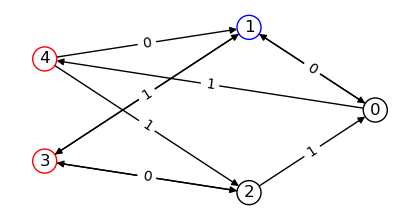

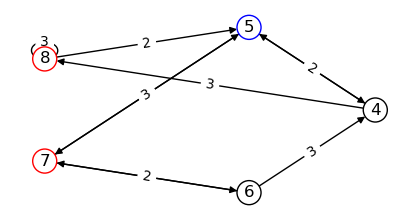

In [32]:
# Example 2: Weak isomorphism is false! Different structure of τ

A1 = (
    {0,1,2,3,4},
    {0,1},
    {   (0,0):1, (0,1):4,
        (1,0):0, (1,1):3,
        (2,0):3, (2,1):0,
        (3,0):2, (3,1):1,
        (4,0):1, (4,1):2},
    1,
    {3,2})

A2 = (
    {4,5,6,7,8},
    {2,3},
    {   (4,2):5, (4,3):8,
        (5,2):4, (5,3):7,
        (6,2):7, (6,3):4,
        (7,2):6, (7,3):5,
        (8,2):5, (8,3):8},
    5, 
    {7,6})

print(is_weak_isomorphic(A1, A2))
visualise(A1, A2, "weak")

(False, None, None)
f = None, g = None


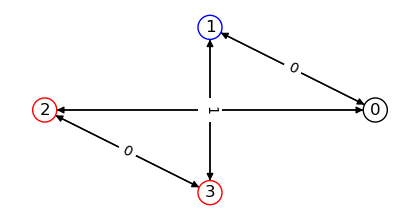

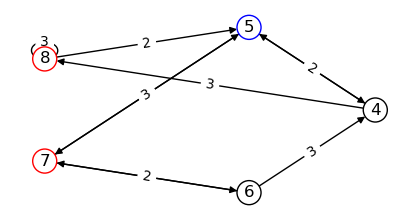

In [33]:
# Example 3: Weak isomorphism is false! Different sizes of Q

A1 = (
    {0,1,2,3},
    {0,1},
    {   (0,0):1, (0,1):2,
        (1,0):0, (1,1):3,
        (2,0):3, (2,1):0,
        (3,0):2, (3,1):1},
    1,
    {3,2})

A2 = (
    {4,5,6,7,8},
    {2,3},
    {   (4,2):5, (4,3):8,
        (5,2):4, (5,3):7,
        (6,2):7, (6,3):4,
        (7,2):6, (7,3):5,
        (8,2):5, (8,3):8},
    5, 
    {7,6})

print(is_weak_isomorphic(A1, A2))
visualise(A1, A2, "weak")

In [34]:
# Example 4: Weak isomorphism is true!
# 1 3, 0 4, 3 2, 2 0, 4 1

A1 = (
    {0,1,2,3,4},
    {0,1},
    {   (0,0):1, (0,1):4,
        (1,0):0, (1,1):3,
        (2,0):3, (2,1):0,
        (3,0):2, (3,1):1,
        (4,0):1, (4,1):2},
    1,
    {3,2})

A2 = (
    {0,1,2,3,4},
    {10,11},
    {   (0,10):2, (0,11):4,
        (1,10):3, (1,11):0,
        (2,10):0, (2,11):3,
        (3,10):4, (3,11):2,
        (4,10):3, (4,11):1},
    3, 
    {2,0})

result, f, g = is_weak_isomorphic(A1, A2)
print(is_weak_isomorphic(A1, A2))
visualisation(A1, A2, f)

(True, {1: 3, 2: 0, 3: 2, 4: 1, 0: 4}, {0: 10, 1: 11})


IntSlider(value=0, description='Step', max=14)

Output()

Output()

### 4.3 Semi-Isomorphism — Examples

Four examples are shown below. We report whether the DFAs are semi-isomorphic and why the result is expected.


In [37]:
def report_semi(A1, A2, label=""):
    ok, f, g = is_semi_isomorphism(A1, A2)
    result = "SEMI-ISOMORPHIC" if ok else "NOT semi-isomorphic"
    print(f"{label}  is  {result}")
    if ok:
        print(f"   f = {f}")
        print(f"   g = {g}")
    print()

# Example 1: Renamed states 
# A2 is A1 with states {0,1} renamed to {10,11}. Expect: semi-isomorphic.
A1_ex1 = ({0,1}, {0,1}, {(0,0):1,(0,1):0,(1,0):1,(1,1):0}, 0, {0})
A2_ex1 = ({10,11}, {0,1}, {(10,0):11,(10,1):10,(11,0):11,(11,1):10}, 10, {10})
print(report_semi(A1_ex1, A2_ex1, "Example 1 (renamed states)"))
result, f, g = is_semi_isomorphism(A1_ex1, A2_ex1)
visualisation(A1_ex1, A2_ex1, f)

# Example 2: Self-loop mismatch 
# A1 has self-loops on symbol 0; A2 has none. Expect: NOT semi-isomorphic.
A1_ex2 = ({0,1}, {0,1}, {(0,0):0,(0,1):1,(1,0):1,(1,1):0}, 0, set())
A2_ex2 = ({10,11}, {0,1}, {(10,0):11,(10,1):11,(11,0):10,(11,1):10}, 10, set())
print(report_semi(A1_ex2, A2_ex2, "Example 2 (self-loop mismatch)"))


# Example 3: Different start/accepting states
# Identical transition structure, different start and accepting states.
# Semi-isomorphism ignores both. Expect: semi-isomorphic.
A1_ex3 = ({0,1,2},{0,1},{(0,0):0,(0,1):1,(1,0):1,(1,1):2,(2,0):2,(2,1):0},0,{0})
A2_ex3 = ({10,11,12},{0,1},{(10,0):10,(10,1):11,(11,0):11,(11,1):12,(12,0):12,(12,1):10},10,{10})
print(report_semi(A1_ex3, A2_ex3, "Example 3 (different start/accepting states)"))
result, f, g = is_semi_isomorphism(A1_ex3,A2_ex3)
visualisation(A1_ex3, A2_ex3, f)


# Example 4: Swapped alphabet roles
# In A1 symbol 0 gives self-loops; in A2 symbol 1 gives self-loops.
# Expect: semi-isomorphic (non-trivial g).
A1_ex4 = ({0,1,2},{0,1},{(0,0):0,(0,1):1,(1,0):1,(1,1):2,(2,0):2,(2,1):1},0,{0})
A2_ex4 = ({10,11,12},{0,1},{(10,0):11,(10,1):10,(11,0):12,(11,1):11,(12,0):11,(12,1):12},12,{11})
print(report_semi(A1_ex4, A2_ex4, "Example 4 (swapped alphabet roles)"))
result, f, g = is_semi_isomorphism(A1_ex4,A2_ex4)
visualisation(A1_ex4, A2_ex4, f)


Example 1 (renamed states)  is  SEMI-ISOMORPHIC
   f = {0: 10, 1: 11}
   g = {0: 0, 1: 1}

None


IntSlider(value=0, description='Step', max=5)

Output()

Output()

Example 2 (self-loop mismatch)  is  NOT semi-isomorphic

None
Example 3 (different start/accepting states)  is  SEMI-ISOMORPHIC
   f = {0: 10, 1: 11, 2: 12}
   g = {0: 0, 1: 1}

None


...

Output()

Example 4 (swapped alphabet roles)  is  SEMI-ISOMORPHIC
   f = {0: 10, 1: 11, 2: 12}
   g = {0: 1, 1: 0}

None


IntSlider(value=0, description='Step', max=8)

Output()

Output()

## 5. Description of Results


### 5.1 Strict Isomorphism

Isomorphism exists (Example 5)
- Example 5 (Renaming states): The states are renamed in the way $0→4, 1→2, 2→0, 3→5, 4→1, 5→3$, with start/accepting states and transition function unchanged. So an isomorphism exists and is precisely this renaming of the states.

Isomorphism does not exist (Examples 1-4)
- Example 1 (Different number of states): The sets $Q_1$ and $Q_2$ does not have same cardinality, so a bijection between them does not exist.

- Examples 2 and 3 (Different start/accepting states): The states and transitions are the same, but starting state and accepting states differ, hence an isomorphism does not exist.

- Example 4 (different transitions): The transition function has been changed, as both DFAs has start state $0$, the map $0→0$ is forced hence no bijection satisfies the isomorphism conditions, an isomorphism does not exist.

### 5.2 Weak Isomorphism

- Example 1 (Weak Isomorphism exists): The function successfully finds bijections $f$ and $g$ satisfying the requirements of weak isomorphism. The state mapping follows $f: 0 → 4, 1 → 5, 2 → 6, 3 → 7, 4 → 8$, and transition label mapping follows $g: 0 → 2, 1 → 3$, hence we have weakly isomorphic DFAs.

- Example 2 (Different structures of $τ$): The function does not find bijections satisfying the conditions for weak isomorphism. In this example, $A_2$ has a state mapping to itself, which isn't the case for $A_1$. No possible mapping can satisfy this structure, therefore weak isomorphism does not exist between these two DFAs.

- Example 3 (Different lengths of $Q$): In this example, $Q_1$ has 4 different states while $Q_2$ has 5, meaning they do not have the same cardinality and there will not be any bijection of $f$ that maps one-to-one for the two DFAs. This means the two DFAs are not weakly isomorphic so the function returns False.

- Example 4 (Weak Isomorphism exists): The function successfully finds bijections $f$ and $g$ satisfying the requirements of weak isomorphism. The state mapping follows $f: 0 → 4, 1 → 3, 2 → 0, 3 → 2, 4 → 1$, and transition label mapping follows $g: 0 → 10, 1 → 11$, hence we have weakly isomorphic DFAs.

### 5.3 Semi-Isomorphism

* Semi-Isomorphism Existence Cases (Examples 1, 3, 4)
For these examples, the algorithm succesfully finds bijections f and g satisfying τ2(f(q), g(a)) = f(τ1(q, a))   for all states q and symbols a.

- In Example 1 of Renamed States: There are two states in each DFA, and the state mapping follows f: 0 → 10, 1 → 11, and the alphabet mapping is the g: identity (unchanged), hence, we see a semi-isomorphism.

- In Example 3 of Altered Start and Accepting states: again we see that this condition does not influence a semi-isomorphism, as it is not a condition, the same is not true for weak and strong isomorphisms. Again we see the mapping g: identity and the the mapping for f: 0 → 10, 1 → 11, 2 → 12, where the states form a 3-cycle, hence there exists a semi-isomorphism.

- In Example 4: Asymmetric Structure with Symbols Swapped: this DFA has three states with an asymmetric structure, even though the alphabet is the same, the roles of the symbols are swapped between the DFAs. In A1, symbol 0 produces self-loops, however, in A2, symbol 1 produces self-loops. The asymmetry ensures a unique mapping for f and demonstrates a non-trivial semi-isomorphism.

* Semi-Isomorphism Non-Existence Case (Examples 2)

- In Example 2: Self-Loop Non-Existence: in this example, A1 has self-loops constructed by 0, while A2 has no self-loops at all. There exists no possible mapping of states that can satisfy this, hence, no semi-isomorphism exists.


## 6. Analysis of Results


### 6.1 Strict Isomorphism

#### **Results as expected?**

Yes, all the results from the function are as expected

#### Analysis of the result being returned
- Example 1: The different cardinalities of the sets of states guarantee that no bijection exist, so no isomorphism exists, i.e. not strictly isomorphic.

  - In the function, False is returned then checking if $|Q_1|=|Q_2|$

- Examples 2 and 3: Both DFAs have the same states, alphabet and transition function. Which means any bijection $f:Q_1→Q_2$ that preserves the transitions must be the identity mapping $I$, but starting state and accepting states differ, so $I$ is not an isomorphism in this case, hence no isomorphism exists, i.e. not strictly isomorphic.

  - In example 2, the function sets $f[0]=1$, but when mapping $1$, only unusued state of $Q_2$ is $0$, which fails $f(F_1)=F_2$, resulting $dive(1)$ and hence $dive(0)$ return False
  - In example 3, similarly, the function sets $f[0]=0$. To map $1$, only $1∉Q_2$ is unusued, but but $1∉F_1$ while $1∈F_2$, untimately resulting a False

- Example 4: This time the DFAs have same states, alphabet and start/accepting states. Suppose there's an isomorphism $f$, then $f$ must map start to start i.e. $f(0)=0$. But with only 2 states, if 0 is fixed and f is a bijection, must have $f(1)=1$, which results $f=I$. Then since $f(τ_1(0,0))=f(1)=1≠0=τ_2(0,0)=τ_2(f(0),0)$, no isomorphism exists, i.e. not strictly isomorphic.

  - In the function, it sets $f[0]=0$, when mapping $1$, only $1∈Q_2$ unusued and $f[1]=1$ fails the consistency check, ultimately resulting a False
 
- Example 5: This succeeds as there exists a bijection (can be thought as a renaming) which satisfies all the isomorphism condtions. The bijection renames in the way $0→4, 1→2, 2→0, 3→5, 4→1, 5→3$ i.e. the permutation $[4, 2, 0, 5, 1, 3]$, which satisfies all the isomorphism condtions. So we found an isomorphism between the DFAs, which implies they are strictly isomorphic

  - The function starts by setting $f[0]=4$, then backtracks until finding $f=[4, 2, 0, 5, 1, 3]$ and verifies that this is an isomorphism, before finally returning True and $f$

### 6.2 Weak Isomorphism

#### **Were the results as expected?** ####
Yes, all the results were as expected, which can be verified using the visualisation graphs.

- Example 1: The function returns True for weak isomorphism between the two DFAs, as well as the $f$ and $g$ mapping. This is clearly shown in the step animation for graphs of the DFAs, where we can see each transition in the first graph, $A_1$, corresponds to the same transition in the second graph, $A_2$.

- Example 2: The function returns False for weak isomorphism between the two DFAs. This is expected since the $f$ and $g$ mapping would be the same as example 1, except for state 8 in the second DFA having a transition state that maps to itself instead of 6. This is different from the structure of the first DFA, which makes the backtracking function fail. This change in structure can be seen very clearly in the visualisation graphs of the two DFAs.

- Example 3: The function returns False for weak isomorphism between the two DFAs. This is also expected since $Q_1$ and $Q_2$ have different cardinalities. This is made very obvious in the visualisation graphs, where $A_1$ clearly has less states than $A_2$.

- Example 4: The function returns True for weak isomorphism between the two DFAs and returns the $f$ and $g$ mapping. This is clearly shown in the step animation graphs for the DFAs. The graphs have the mapped numbers in the same places so that the mapping between the $A_1$ and $A_2$ is clear.

### 6.3 Semi-Isomorphism

### Were the results as expected?

Yes, all four outcomes match the predictions in the example descriptions, and the returned bijections can be verified.

**Positive cases (Examples 1, 3, 4)**

Examples 1 and 3 are straightforward: the two DFAs are structurally identical with renamed states, so $g$ is the identity on the alphabet and $f$ is a simple offset $f(i) = 10 + i$.

For Example 4, this isn't the case The backtracking search starts at root pair $(0, 10)$ and immediately encounters symbol $0$. In $A_1$, $(0, 0) \to 0$ is a self-loop; the algorithm must find $b \in \{0,1\}$ such that $\tau_2(10, b) = 10$. Checking: $\tau_2(10, 0) = 11 \neq 10$, but $\tau_2(10, 1) = 10$. So the only consistent assignment is $g(0) = 1$, and all remaining constraints follow easily with no further backtracking needed. This shows that the algorithm recovers a non-trivial $g$ efficiently from a single forced step.


**Negative case (Example 2)**

Failure is detected at the first undetermined step (Case 4 of `backtrack`). For any root pairing, the algorithm needs $\tau_2(f(q), b) = f(q)$ to match $A_1$'s self-loop, but no state in $A_2$ has a self-loop under any symbol. Every candidate $b$ is immediately rejected, for every root pairing.

## Factors influencing the algorithm

1. **Alphabet asymmetry** - The symbol mapping isn’t always identity; a single root constraint often fixes it automatically.  
2. **State role asymmetry** - States with different roles (cycle vs. tail) immediately determine the mapping, speeding up the search.  
3. **Self-loop check** - Fails instantly if required self-loops aren’t present.  
4. **Root SCC size** - Bigger initial SCCs mean more root pairings, so slower processing.



## 7. Who Did What

We divided the project into two parts: Finlay, James, and Somhairle worked on Part 1 (synchronisation); Elena, Ella, and Fei worked on Part 2 (isomorphism). Within Part 2, Fei implemented strict isomorphism, Elena implemented semi-isomorphism, and Ella implemented weak isomorphism. Each team member wrote the description and analysis for their own component; the group then collaborated on the introduction, Part 3 extensions, and final report assembly.


## 8. Beyond the Project Specification

*(To be completed — describe any Part 3 contributions here.)*


In [ ]:
#NOT FINISHED YET! - James
#ive generated some DFAs using the generate_dfa and timed them (used the solutions from tutorial sheet 3)
#need to work out the print part but it works
from time import process_time

n1, m1, f_size1 = 4, 3, 2
n2, m2, f_size2 = 5, 3, 2
n3, m3, f_size3 = 8, 3, 2

DFA_1 = generate_dfa(n1, m1, f_size1)
DFA_2 = generate_dfa(n2, m2, f_size2)
DFA_3 = generate_dfa(n3, m3, f_size2)
DFA_list = [DFA_1, DFA_2, DFA_3]

def timing_of_algorithm(DFA,algorithm):
    start = process_time()
    for i in range(10):
        algorithm(DFA)
    stop = process_time()
    elapsed = stop - start
    print(f"DFA{elapsed}")
    return elapsed

for DFA in DFA_list:
    timing_of_algorithm(DFA,breadth_first_synch_test)

### Canonicalisation and minimization of DFAs, and how it is realated to isomorphisms

Large DFAs come up often in computing, and if it is too complicated, it will take up large amounts of computer memory and is very inefficient. 

So does there exist a simpler DFA with same 'structure' as the original DFA? 

The short answer is yes, and this is the minimal DFA, which is obtained by applying the process of minimization to a DFA.

First, we will introduce some concepts and definitions:

- For a given DFA $A=(Q,Σ,τ,q_s,F)$, let $Σ^*$ be the set of all *words* over the alphabet $Σ$, which are finite strings formed using the letters of $Σ$ and $τ^*$ be the transition function on words (what was defined as $t$ in the strict isomorphism section when discussing if synchronizing properties were preserved).

- The *language* of $A$ is the set $L(A)=\{w∈Σ^*: τ^*(q_s,w)∈F\}$, which can be thought as the words that when the DFA processes (from the start state), it end on a accepting state.

- Two DFAs are *equivalent* if and only if they accept the same language

Minimization of a DFA $A$ is the process to transform/reduce $A$ into an equivalent DFA that has the least possible states, which we will  call $min(A)$. The minimal DFA $min(A)$ usually has much less states than the original DFA $A$ so makes work much easier and faster.

There are several methods to minimise a DFA, here we will discuss the Partition Refinement Algorithm which is not the most efficent but a very intuitive method. This method starts by splitting states of the DFA into final (accepted) and non-final states, and then reapeatedly split groups based on if the states in one group end up on different groups when transitioned using a (same) letter.

This works intuitively as after the algorithm, every group has the same output group after being transitioned by a letter (it does not depend on which state is chosen in the group, all the states are mapped to some state in the same output group by the same letter), so we can jusy 'group A is transitioned to group B by 0', and the groups essentially act as states in the minimal DFAs.

Proof (accept same language): https://math.stackexchange.com/questions/1105220/proof-dfa-defines-same-language-as-minimal-dfa/1105633

Given a DFA $A=(Q,Σ,τ,q_s,F)$ the algorithm does:
- Split Q into two groups, one consisting of the final states, and the other consisting of the non-final states

- For the group of non-final states, check if using *any* letter on every state of the group will end up on different groups. If thats the case, then this group is splitted into groups which end on the same group (not the original group, but that these elements end on states inside same group after transitioned) after transitioned by that letter. Otherwise this group can not be split

- Repeat the process for the group of final states

- If no new groups are generated, the minimization is done, otherwise repeat the process for the newly split groups to further split them

- Repeat until every group can not be split further, the resulting groups are the states of min(A)

- Lastly, find the transitions between the states.

**As an example consider the following DFA shown below, it has states $\{0,1,...,5\}$, alphabet $\{0,1\}$, accepting states $\{2,3,5\}$ and start state $1$ (transitions shown in plot):**

In [ ]:
# function to draw DFA. 

import matplotlib.pyplot as plt
import networkx as nx

def draw_DFA(A):
    Q, sigma, tau, qs, F = A
    G = nx.MultiDiGraph()

    for (fromm, alpha), to in tau.items():
        G.add_edge(fromm, to, label = alpha)

    pos = nx.spring_layout(G)
    plt.figure()
    nx.draw(G, pos, with_labels = True)
    edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data = True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels = edge_labels)
    plt.show()
A=({0,1,2,3,4,5},{0,1},{(0,0):1,(0,1):2,(1,0):0,(1,1):3,(2,0):5,(2,1):4,(3,0):5,(3,1):4,(4,0):4,(4,1):4,(5,0):5,(5,1):4},1,{2,3,5})
draw_DFA(A)

- First split the states into groups $\{0,1,4\}$ and $\{2,3,5\}$

- $0$ does not split $\{0,1,4\}$ but $1$ does, since $τ(4,1)=4∈\{0,1,4\}$ but $τ(0,1)=2, τ(0,1)=3∈\{2,3,5\}$. Splitted into $\{0,1\}$ and $\{4\}$.

- The group $\{2,3,5\}$ can not be further split.

- The group $\{0,1\}$ can not be further split.

- The group $\{4\}$ can not be further split.

- This is the states of $min(A)$, now find the transitions:

  - reading $0$ in $\{0,1\}$ remains in $\{0,1\}$, while $1$ goes to $\{2,3,5\}$

  - $\{4\}$ remains $\{4\}$ for both $0$ and $1$
 
  - reading $0$ in $\{2,3,5\}$ remains in $\{2,3,5\}$, reading $1$ goes to $\{4\}$
 
We are done, to plot this minimised DFA, as our code only works on states $0,1,...,n-1$, rename the set $\{0,1\}$ as $0$, $\{2,3,5\}$ as $1$,  $\{4\}$ as $2$. Then the plot is shown below.

In [ ]:
minA=({0,1,2},{0,1},{(0,0):0,(0,1):1,(2,0):2,(2,1):2,(1,0):1,(1,1):2},0,{1})
draw_DFA(minA)

So what if we have a large DFA, and there are several choices to the order in applying this algorithm, will we yield different minimal DFAs?

It turns out that we *do* infact get different different minimised DFAs, but up to *renaming the states* i.e. The minimal DFA of a DFA is unique up to renaming the states, which makes these minimal DFAs an ideal canonical form. Recall that two DFAs are strictly isomorphic if they are same up to renaming the states, so we come to the following conclusion:

**Two DFAs are equivalent i.e. accept same language if and only if their minimised forms are isomorphic**

The proof: https://people.cs.uchicago.edu/~simon/OLD/COURSES/OldCS28000/Lectures/10.html

This is an efficient way of determining if large DFAs accpets same language. Given DFAs $A$ and $B$, we just need to check if $min(A)$ and $min(B)$ are isomorphic.

## 9. Use of AI

The original recursive Backtrack implementation was converted to an iterative stack-based approach to avoid Python recursion limits. Claude suggested the stack approach.
